In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
%reload_ext autoreload

In [55]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mydata/cope/mirco/data/ssp585_time_series.pkl'

In [3]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

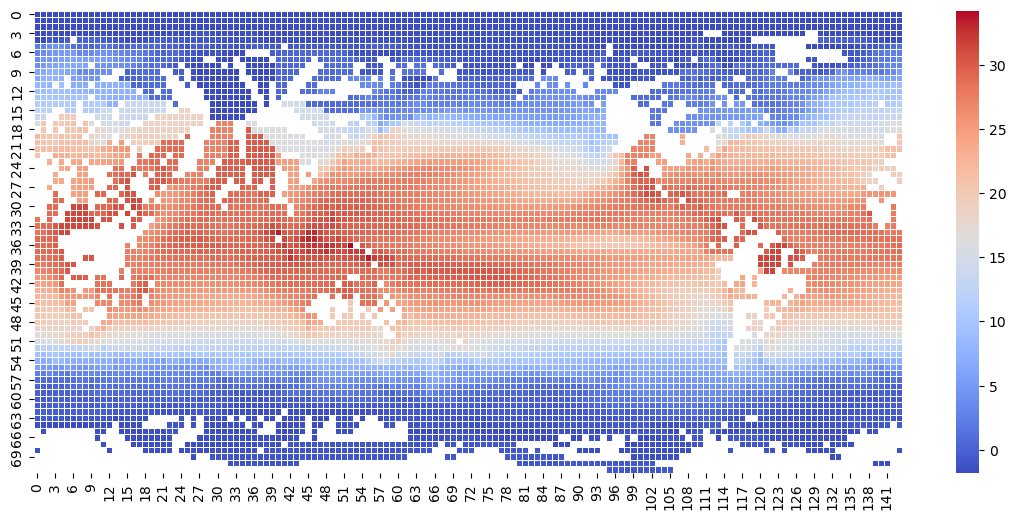

In [ ]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

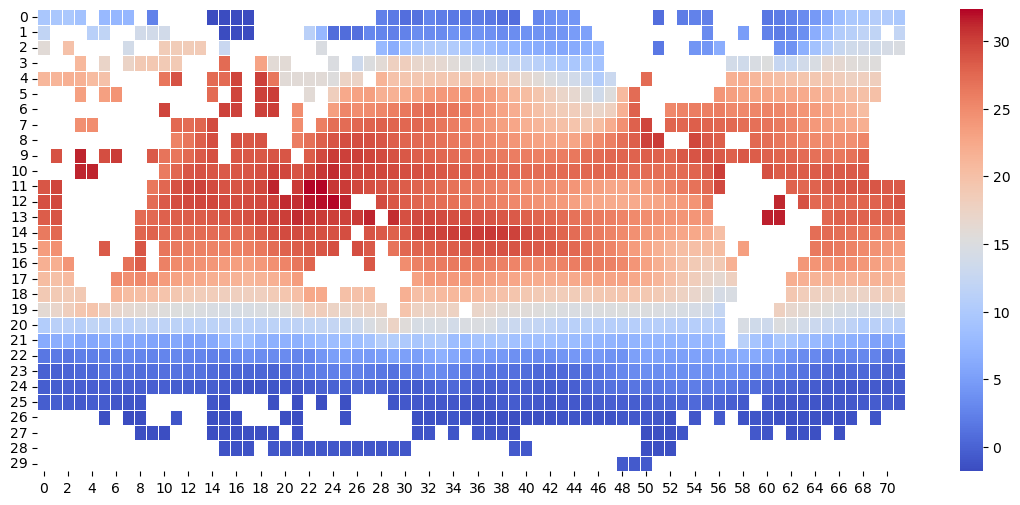

In [5]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

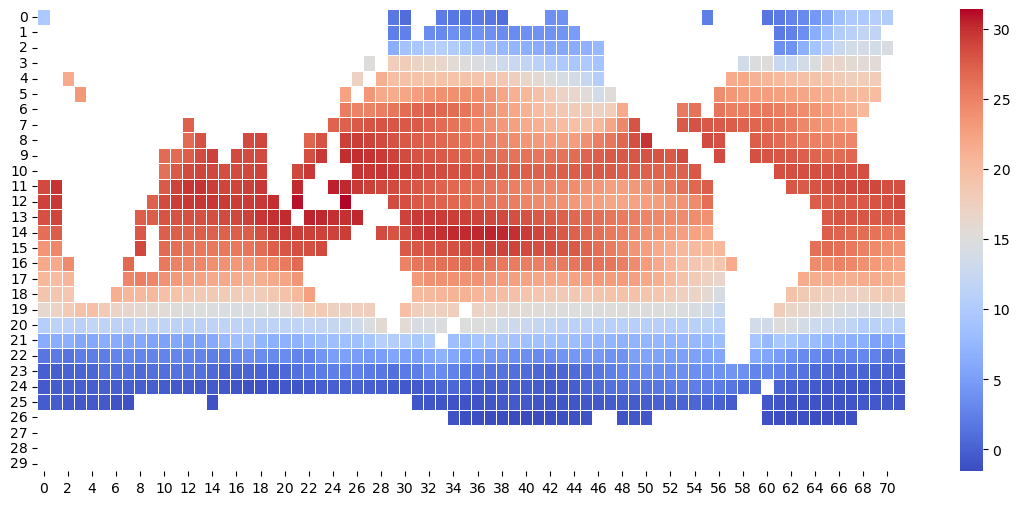

In [6]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [7]:
X, Y = extract_matrices(cope_data, union_nan_mask)

In [9]:
X.shape

(23539, 1308)

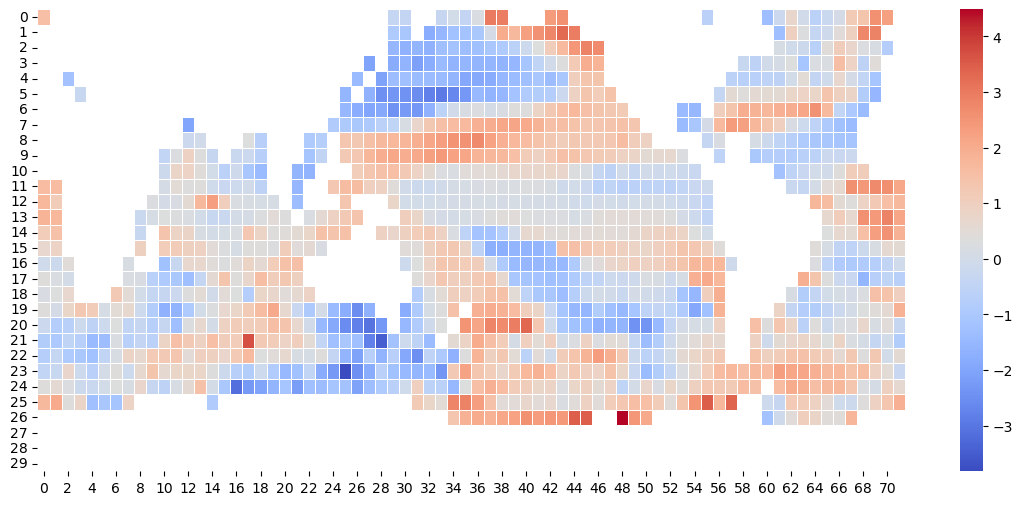

In [19]:
plot_grid(from_flat_to_grid(X[12], union_nan_mask))

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [8]:
batch_size = 32

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
lr = 1e-3
epochs = 20

model = basic_VAE(input_dim=1308, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training basic VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  163.25656038401078
Epoch 2 complete ! 	Average Loss:  132.05340954073432
Epoch 3 complete ! 	Average Loss:  67.32485402684634
Epoch 4 complete ! 	Average Loss:  59.32775652489695
Epoch 5 complete ! 	Average Loss:  60.66870590780868
Epoch 6 complete ! 	Average Loss:  60.746535823458714
Epoch 7 complete ! 	Average Loss:  50.82728523137618
Epoch 8 complete ! 	Average Loss:  50.884343397049676
Epoch 9 complete ! 	Average Loss:  48.34137679768257
Epoch 10 complete ! 	Average Loss:  48.932538775359696
Epoch 11 complete ! 	Average Loss:  50.81439305649323
Epoch 12 complete ! 	Average Loss:  44.68532941454933
Epoch 13 complete ! 	Average Loss:  46.17693250357699
Epoch 14 complete ! 	Average Loss:  42.960508628767364
Epoch 15 complete ! 	Average Loss:  41.925070272821955
Epoch 16 complete ! 	Average Loss:  40.69586903059564
Epoch 17 complete ! 	Average Loss:  46.12225271731007
Epoch 18 complete ! 	Average Loss:  40.69574149774046
Epoch 19

In [ ]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)

        break

In [160]:
x.shape

torch.Size([32, 1308])

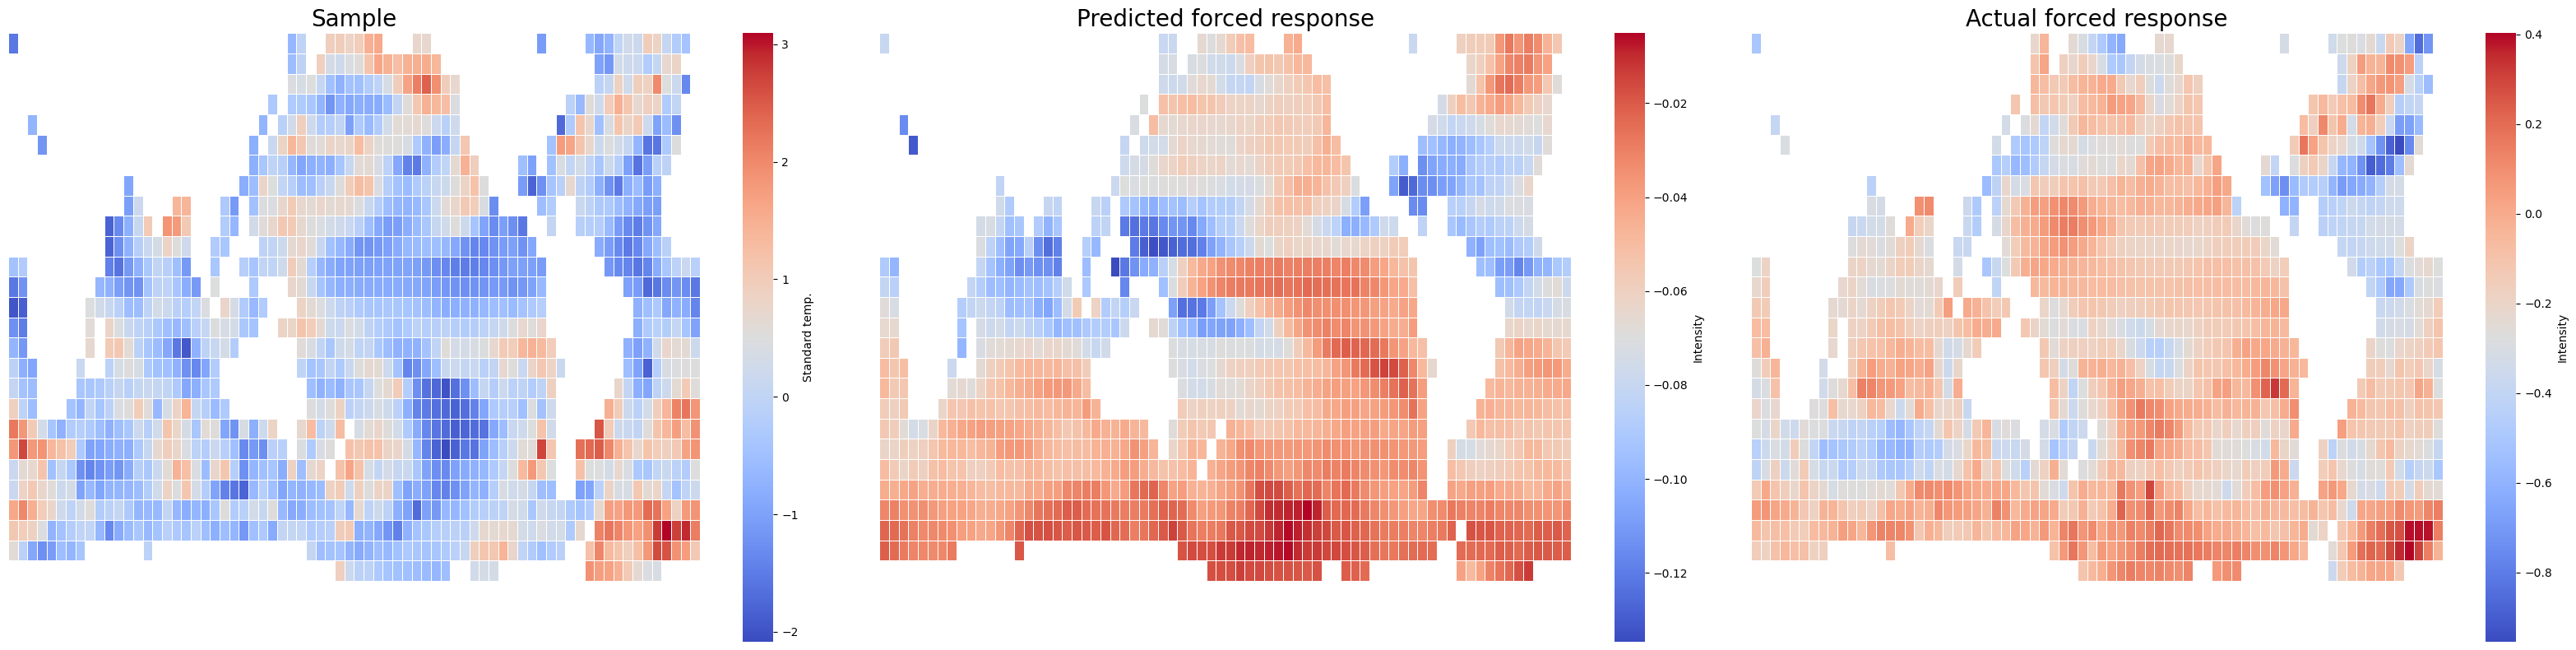

In [161]:
index = 1
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

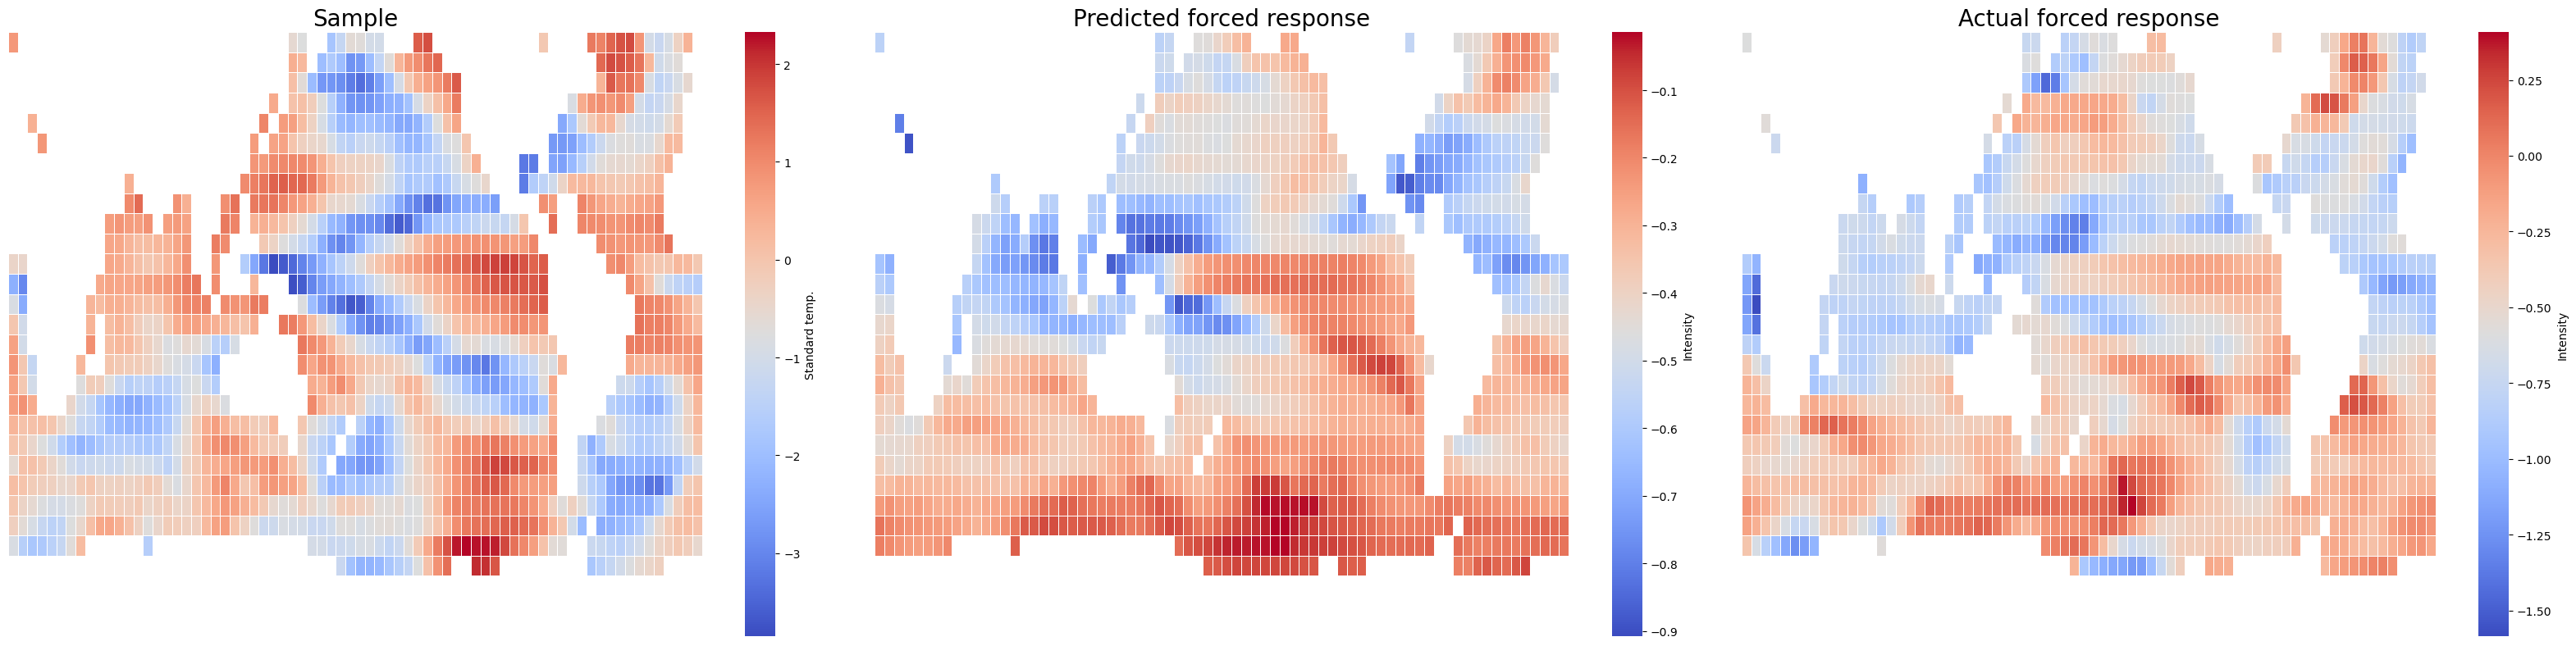

In [169]:
index = 25
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

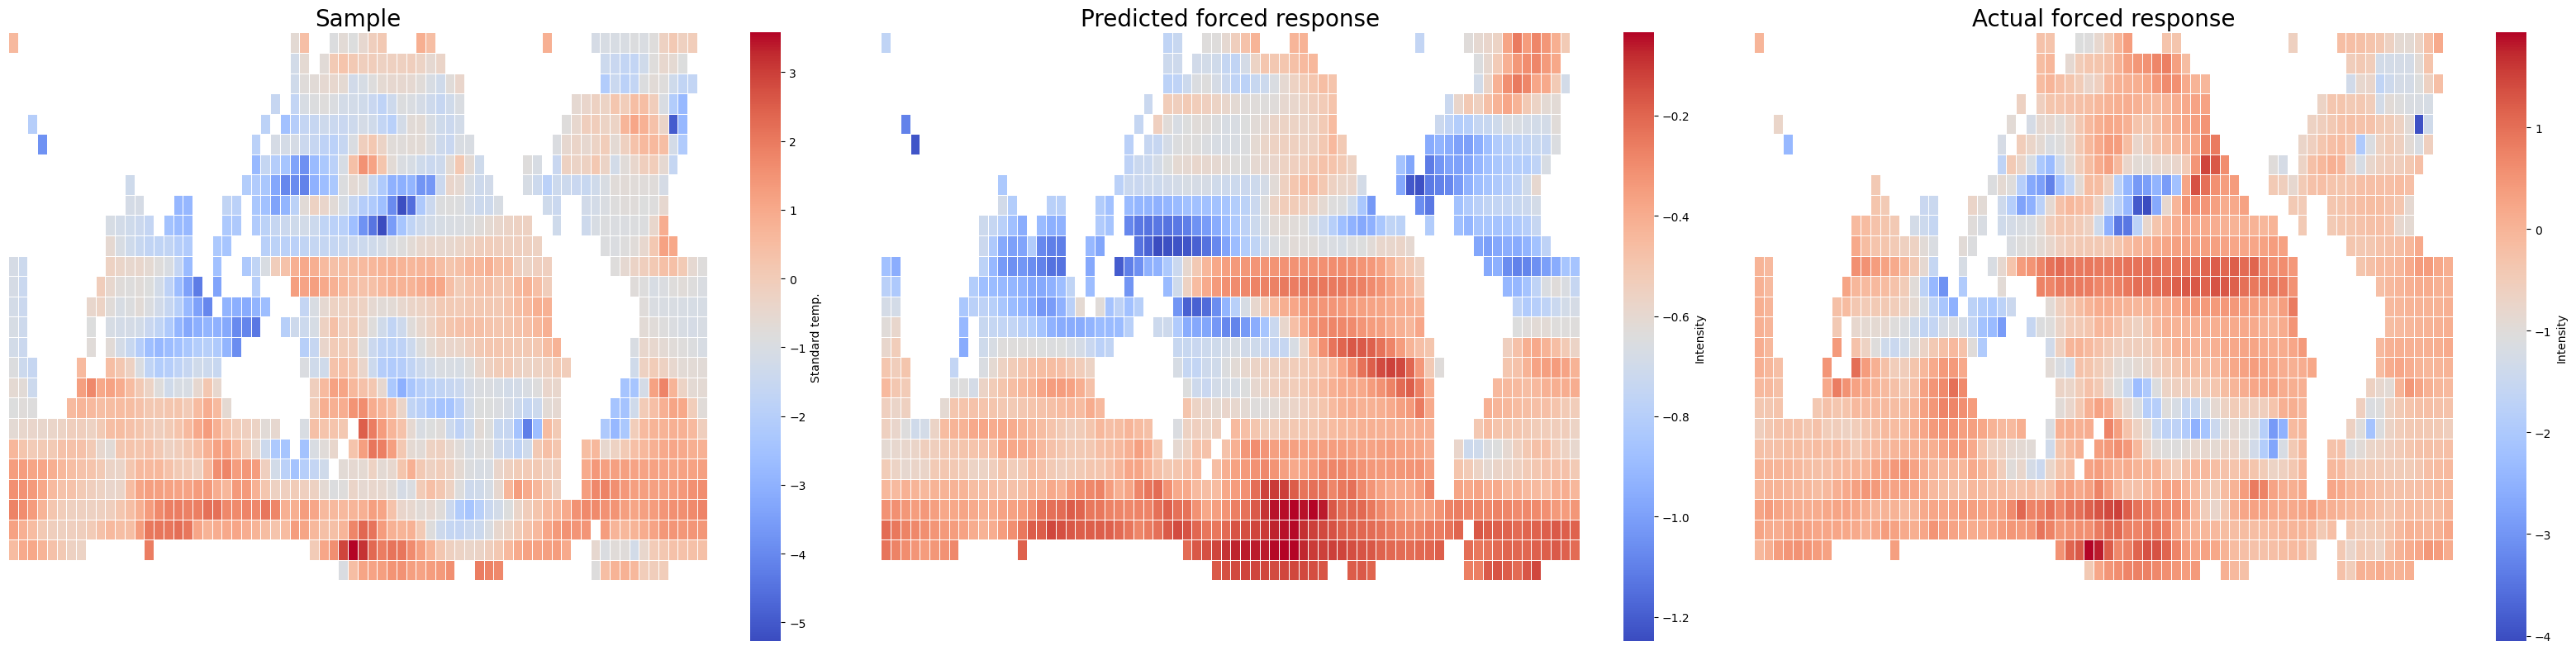

In [163]:
index = 3
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

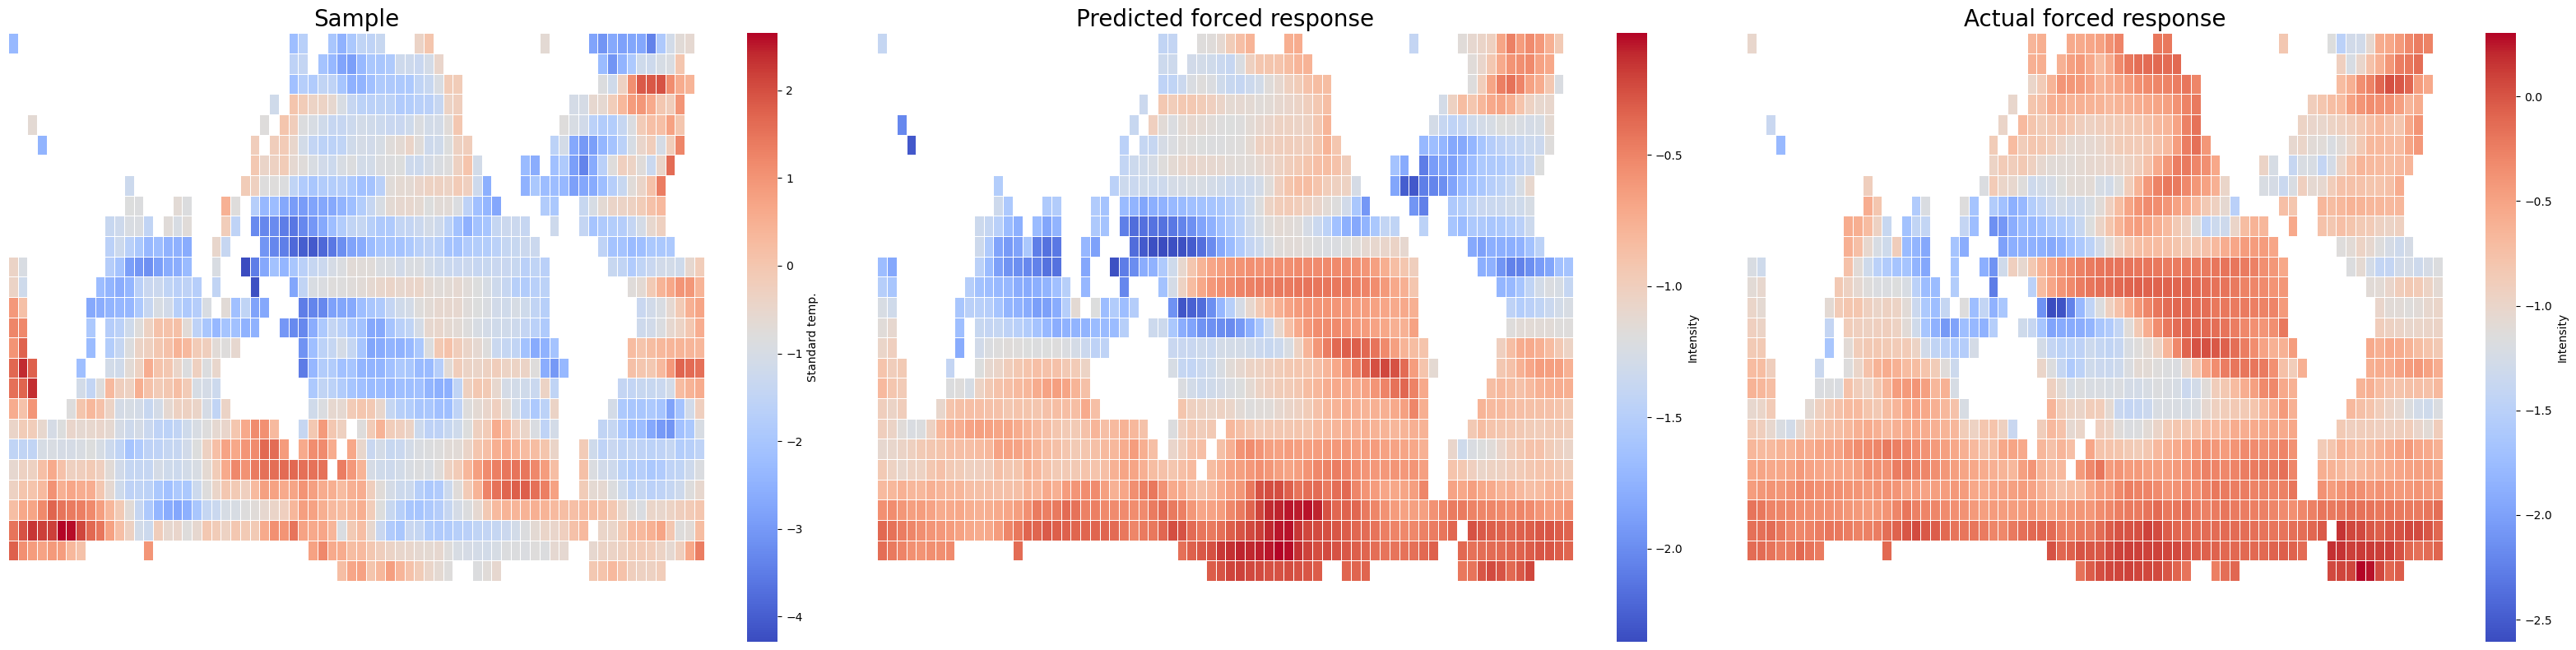

In [164]:
index = 4
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

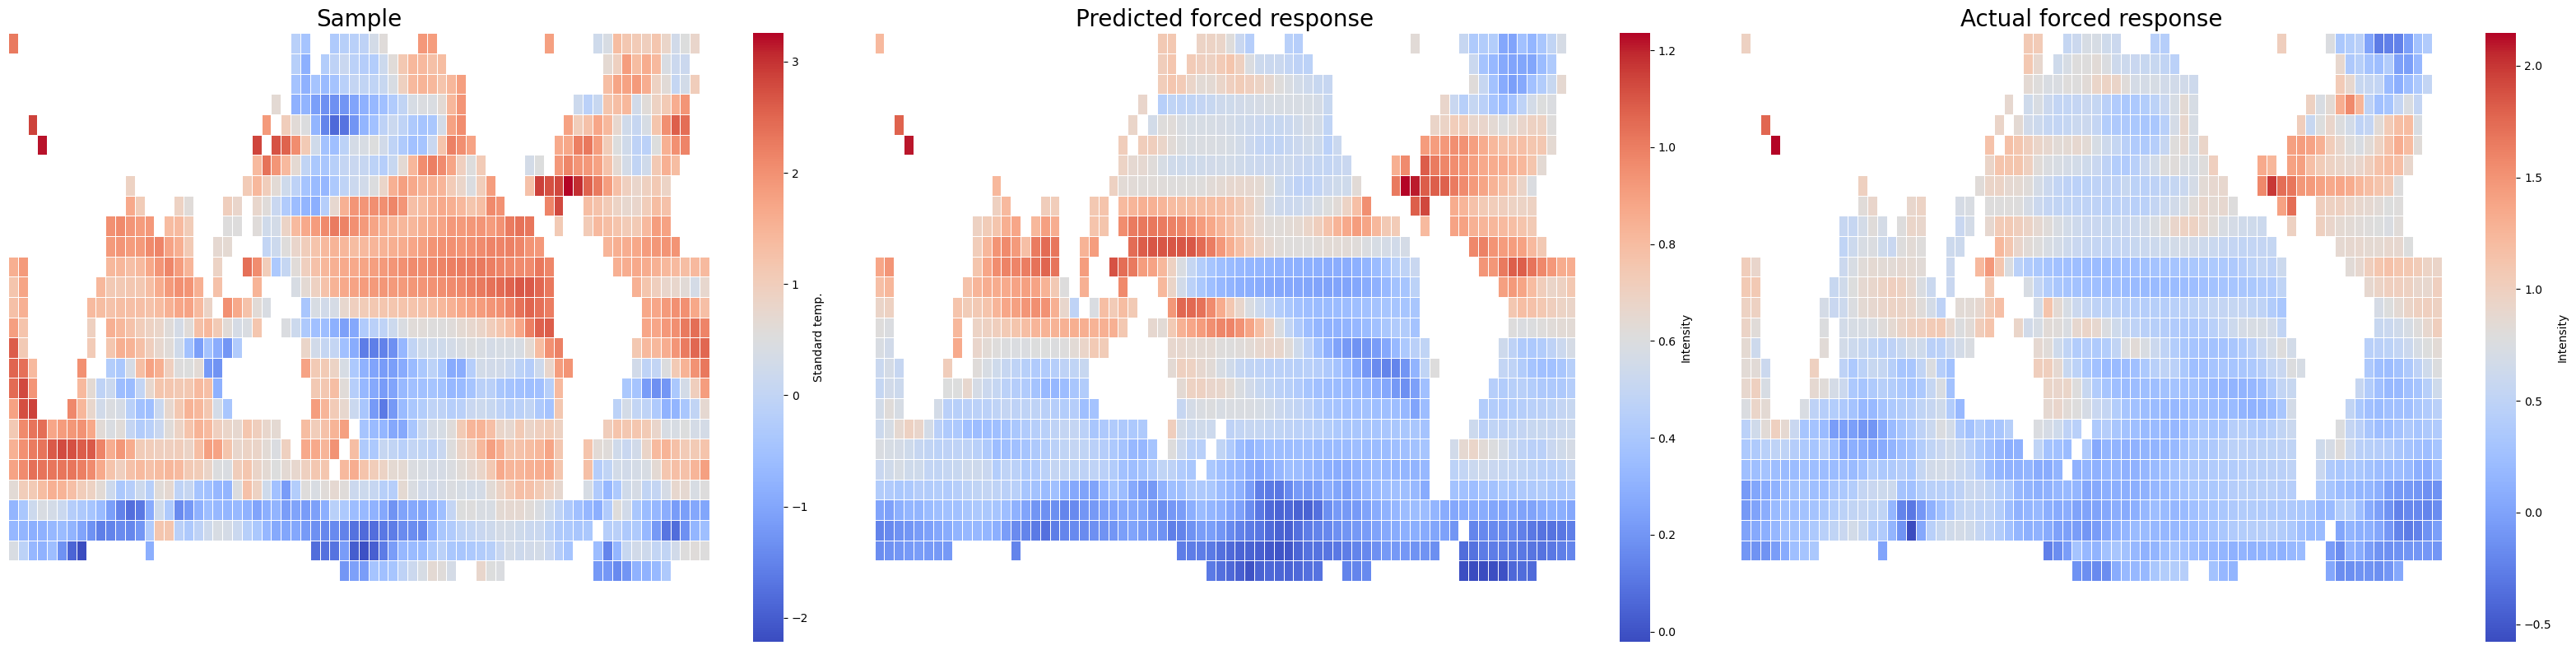

In [165]:
index = 5
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [11]:
lr = 1e-3
epochs = 20

model = VAE(input_dim=1308, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  90.72927570343018
Epoch 2 complete ! 	Average Loss:  28.053768981881692
Epoch 3 complete ! 	Average Loss:  5.042564398577424
Epoch 4 complete ! 	Average Loss:  -3.033572028283359
Epoch 5 complete ! 	Average Loss:  -6.452130220374283
Epoch 6 complete ! 	Average Loss:  -7.814184727311945
Epoch 7 complete ! 	Average Loss:  -8.355356728949515
Epoch 8 complete ! 	Average Loss:  -10.8555904894459
Epoch 9 complete ! 	Average Loss:  -11.121342393005786
Epoch 10 complete ! 	Average Loss:  -11.256085791555392
Epoch 11 complete ! 	Average Loss:  -12.937062591111578
Epoch 12 complete ! 	Average Loss:  -12.663391989104602
Epoch 13 complete ! 	Average Loss:  -13.444233874885404
Epoch 14 complete ! 	Average Loss:  -14.511172417880726
Epoch 15 complete ! 	Average Loss:  -14.46718252921591
Epoch 16 complete ! 	Average Loss:  -13.235291299365816
Epoch 17 complete ! 	Average Loss:  -14.603218500306006
Epoch 18 complete ! 	Average Loss:  -16.7172569

In [16]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

In [17]:
x.shape

torch.Size([32, 1308])

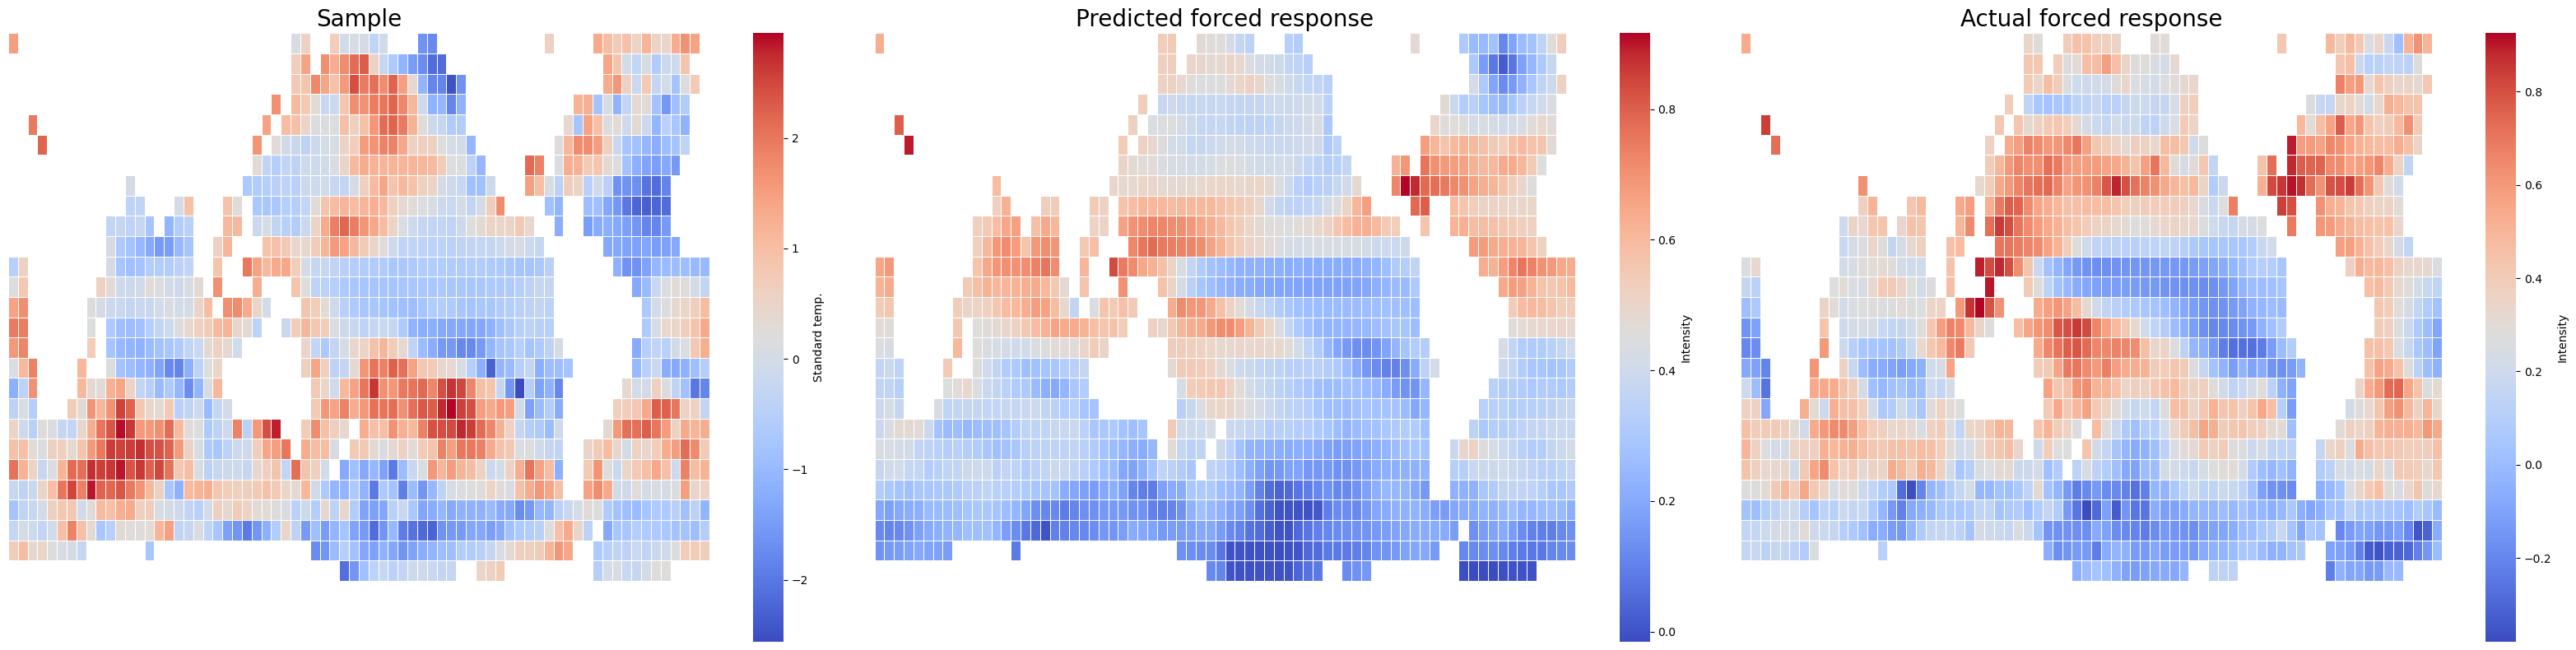

In [29]:
index = 12
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [38]:
import os
os.environ['PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT']='2'

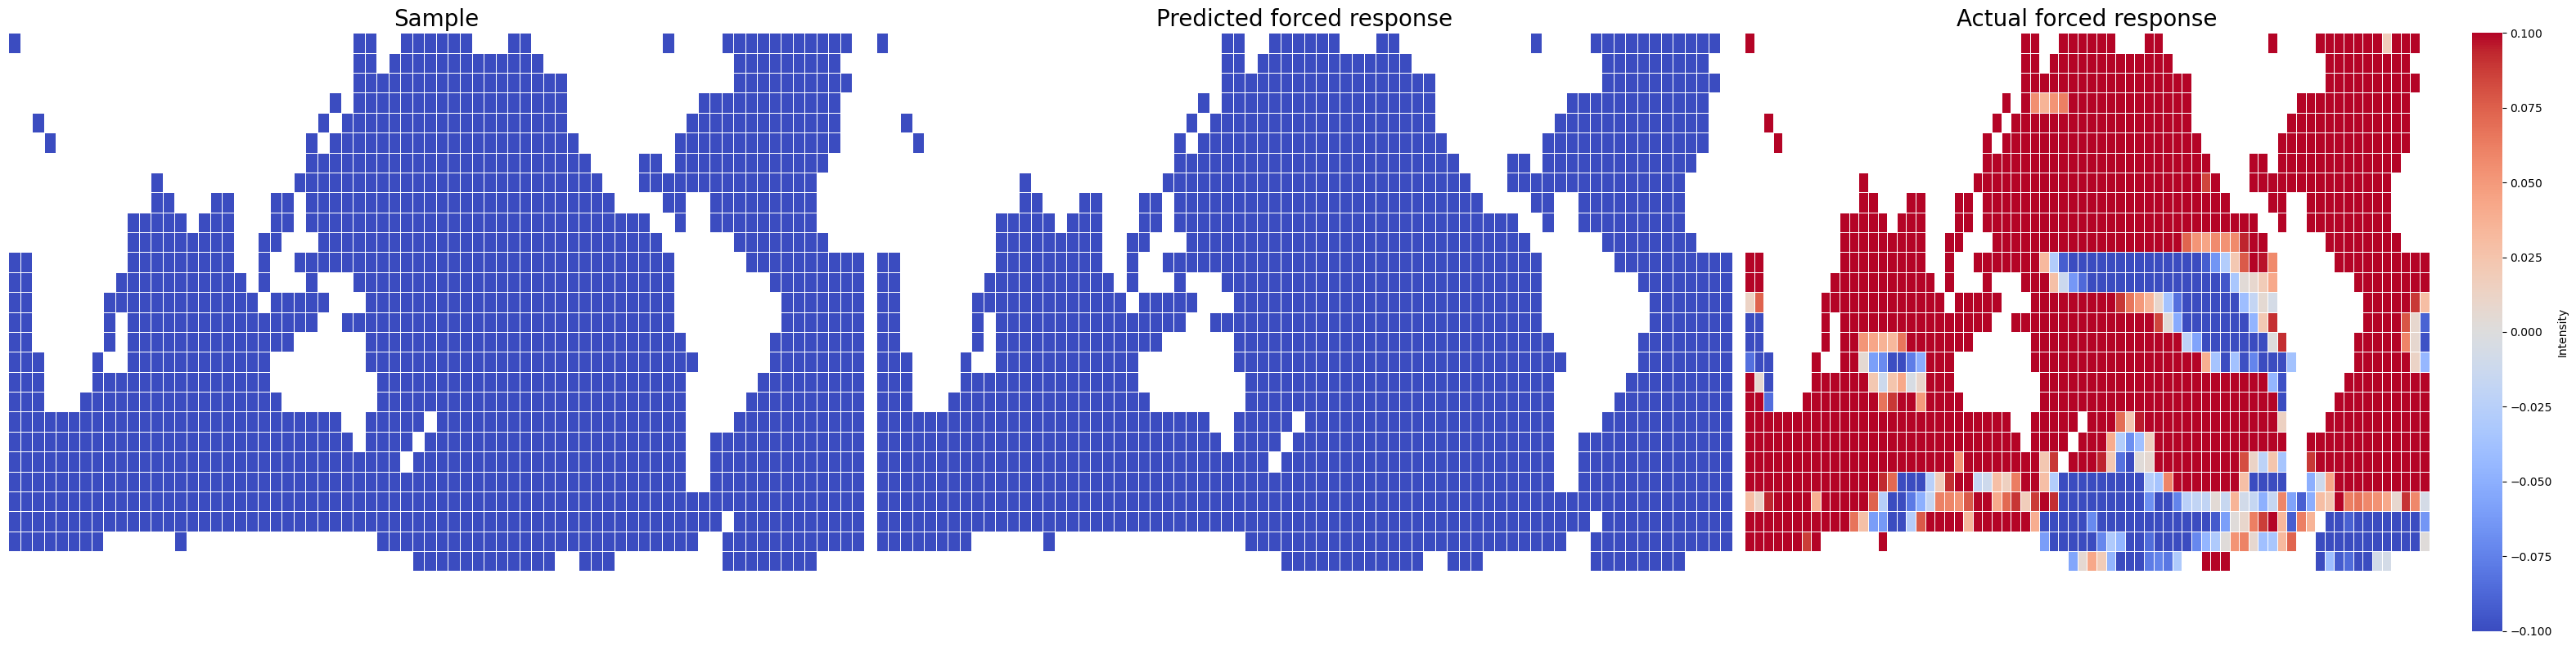

In [81]:
from plots import plot_trio_grids

index = 12
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [52]:
min((x[index].ravel().min(), x_hat[index].ravel().min()))

tensor(-2.5609)

In [53]:
x[index].ravel().max()

tensor(2.9485)